***
***

# ***HR CASE STUDY***

***
***

## Understanding the Business Context and Problem

This is the data of a company provided by the HR Department and they want to analyse this data and find out the actual cause of leaving the company by employees and also want a model who predict whether an employee will leave the company or not.
It will become easy for the HR department to predict and take some necessary steps so,that the employee will retain in the company because it is very time consuming and expensive process to find or hire a new employee, increasing retention of employees will be beneficial to the company.

## Familarize with the data

This data contains 14,999 rows and 10 columns.
I provided data dictionary below so that we can understand the data fields:

| Column   | Description |
|----------|-------------|
| Satisfaction_level    |   The employee's self_reported satisfaction level [0-1]          |
| last_evaluation |     Score of employee's last performance review [0-1]       |
| number_project |       Number of projects employee contributes to      |
| average_monthly_hours |  average number of hours employee worked per month           |
| time_spend_company |      How long the employee has been in the company(in years)          |
| work_accident |     whether or not an employee experienced an accident while at work                |
| left               |     whether or not the employee left the company               |
| promotion_last_5_years         |   whether or not the employee was promoted in the last 5 years                     |
|       department        |     The employee's department                   |
|          salary     |           The employee's salary (low,medium,high)              |


After analysing the business problem and by looking the data dictionary I can say that my target column would be 'left' . So, for  analysis I will mainly focus on this left variable with other variables for finding the relation between this variable with others.




***

### Importing Libraries

In [479]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder,PowerTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve,accuracy_score,f1_score,
                             cohen_kappa_score,precision_score,recall_score)
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
import warnings
warnings. filterwarnings('ignore')

In [388]:
data = pd.read_csv('HR_capstone_dataset.csv')
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [389]:
# Looking the rows and columns in the data
print('Total number of rows in the data', data.shape[0])
print('Total number of columns in the data',data.shape[1])

Total number of rows in the data 14999
Total number of columns in the data 10


### ***Exploring the data***

In [390]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


By looking the info of the data , we egt some inferences as below:
* There is no missing values present in the data.
* There is some numerical columns and categorical columns in the data.
* Here our target variable is left which is in categorical form.



In [391]:
# By looking the data I renamed some columns because of some spelling errors  or due to inconsistent naming convention. 
# This will help for our smoother analysis.
data = data.rename(columns = {'number_project':'number_of_projects','average_montly_hours':'avg_monthly_hours','time_spend_company':'tenure',
                             'Work_accident':'work_accident','left':'Exit_status','Department':'department' })



In [392]:
data.head(2)

,satisfaction_level,last_evaluation,number_of_projects,avg_monthly_hours,tenure,work_accident,Exit_status,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium


In [393]:
# 5 point summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_of_projects,14999.0,3.803054,1.232592,2.00,3.00,4.00,5.00,7.0
avg_monthly_hours,14999.0,201.050337,49.943099,96.00,156.00,200.00,245.00,310.0
tenure,14999.0,3.498233,1.460136,2.00,3.00,3.00,4.00,10.0
work_accident,14999.0,0.144610,0.351719,0.00,0.00,0.00,0.00,1.0
Exit_status,14999.0,0.238083,0.425924,0.00,0.00,0.00,0.00,1.0
promotion_last_5years,14999.0,0.021268,0.144281,0.00,0.00,0.00,0.00,1.0


By looking this 5 point summary we can find that :
* work_accident,Exit_status,promotion_last_5_years,number_of_projects,tenure these all are the categorical columns in numerical form 
* while the rest of the columns are numerical columns
* maximum number of projects done by an employee is 7
* most of the employees stay in this company for 4 years and some stay for 10 years at max.


In [394]:
# Unique values present in the data
data.nunique()

satisfaction_level        92
last_evaluation           65
number_of_projects         6
avg_monthly_hours        215
tenure                     8
work_accident              2
Exit_status                2
promotion_last_5years      2
department                10
salary                     3
dtype: int64

In [395]:
# Looking for what are the unique categories in the categorical column
print('Unique categories in Department', data.department.unique())
print('Unique values in Tenure', data.tenure.unique())
print('Unique categories in Salary', data.salary.unique())
print('Unique values in Number of projects', data.number_of_projects.unique())


Unique categories in Department ['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']
Unique values in Tenure [ 3  6  4  5  2  8 10  7]
Unique categories in Salary ['low' 'medium' 'high']
Unique values in Number of projects [2 5 7 6 4 3]


***

### DATA CLEARNING

#### Looking for Missing Values in the data

In [396]:
data.isnull().sum().sum()
# No Missing values present in the dataset.

np.int64(0)

#### Visualizing and Treating Duplicates in the data

In [397]:
data.duplicated().sum()

np.int64(3008)

In [398]:
data[data.duplicated()]

,satisfaction_level,last_evaluation,number_of_projects,avg_monthly_hours,tenure,work_accident,Exit_status,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


The data has 3008 duplicate rows which is around 20% of the data is duplicated .By looking this duplicate entries I am removing these all duplicated entries 
for better visualization of data

In [399]:
# treating duplicated data
data.drop_duplicates(keep='first',inplace=True)

In [400]:
data.shape

(11991, 10)

***

### ***Visualization***

#### Univariate Analysis

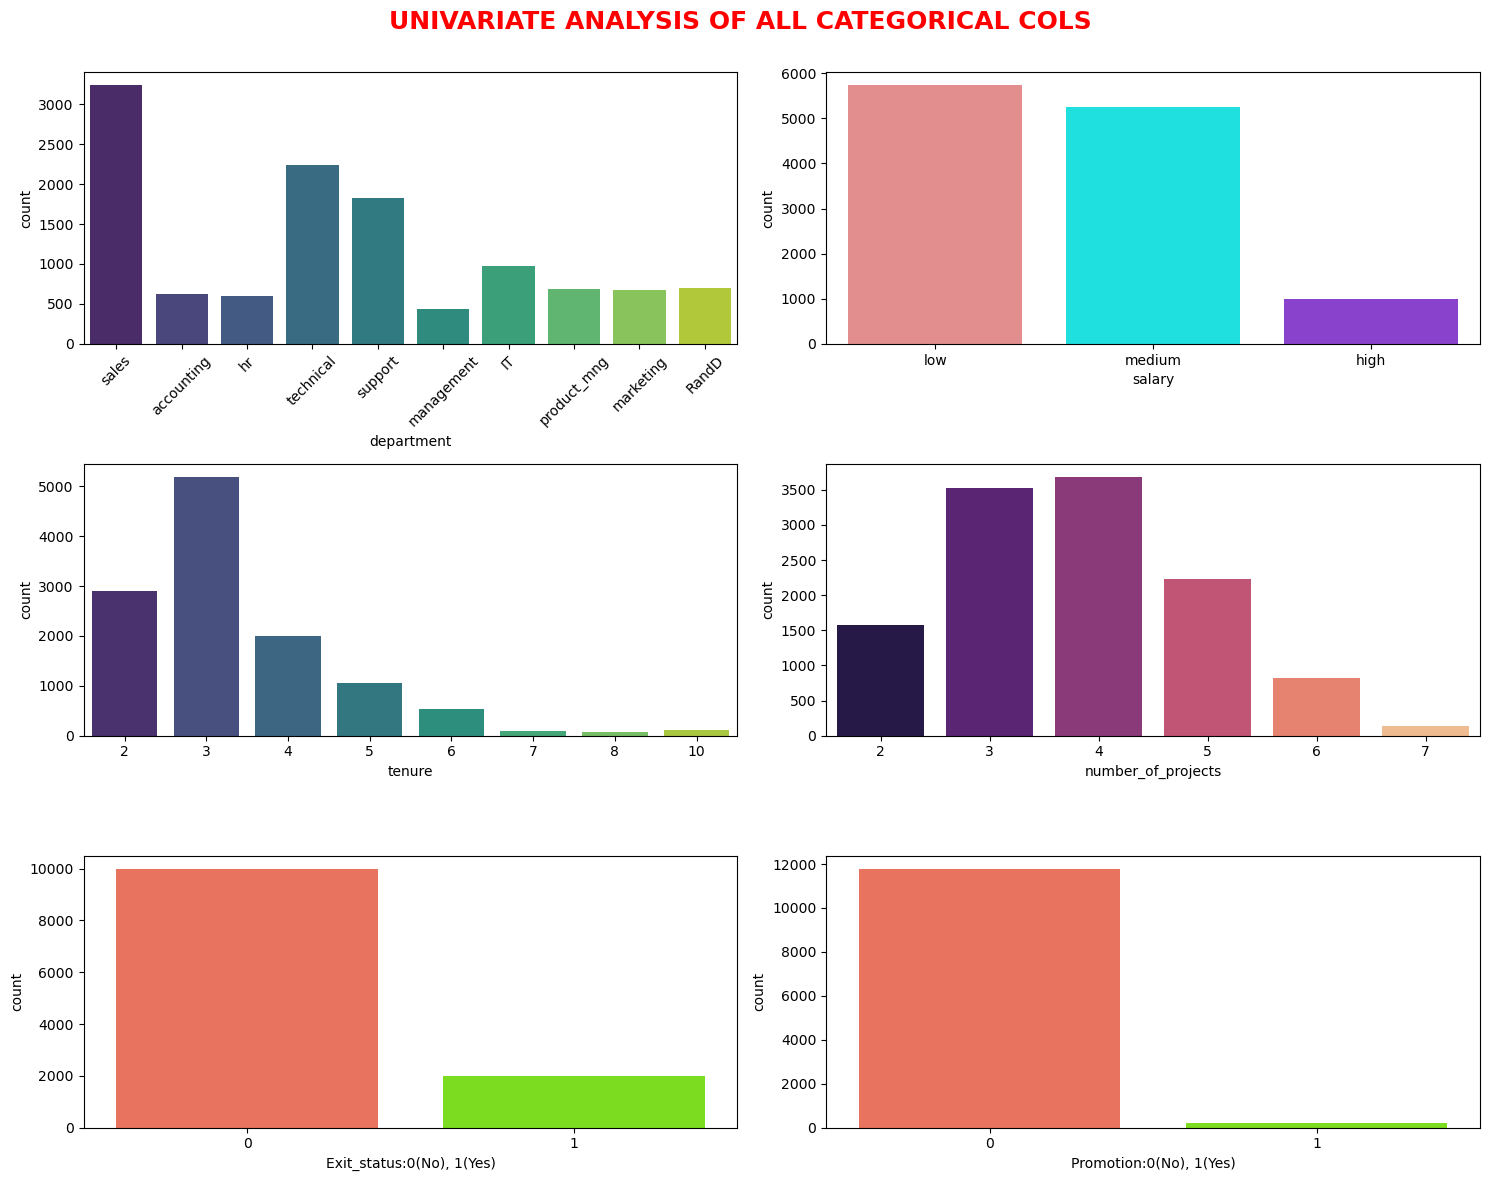

In [401]:
# All categorical columns
fig, ax = plt.subplots(3, 2, figsize=(15, 12))
plt.suptitle('UNIVARIATE ANALYSIS OF ALL CATEGORICAL COLS \n',fontweight='bold',color='red',size=18)
sns.countplot(data,x='department',ax=ax[0,0],palette='viridis')
ax[0,0].tick_params(axis='x',rotation=45)
sns.countplot(data,x='salary',ax=ax[0,1],palette=['lightcoral','cyan','blueviolet'])
sns.countplot(data,x='tenure',ax=ax[1,0],palette = 'viridis')
sns.countplot(data,x='number_of_projects',ax=ax[1,1],palette = 'magma')
sns.countplot(data,x='Exit_status',ax=ax[2,0],palette=['tomato','lawngreen'])
ax[2,0].set_xlabel('Exit_status:0(No), 1(Yes)')
sns.countplot(data,x='promotion_last_5years',ax=ax[2,1],palette = ['tomato','lawngreen'])
ax[2,1].set_xlabel('Promotion:0(No), 1(Yes)')
plt.tight_layout()
plt.show()



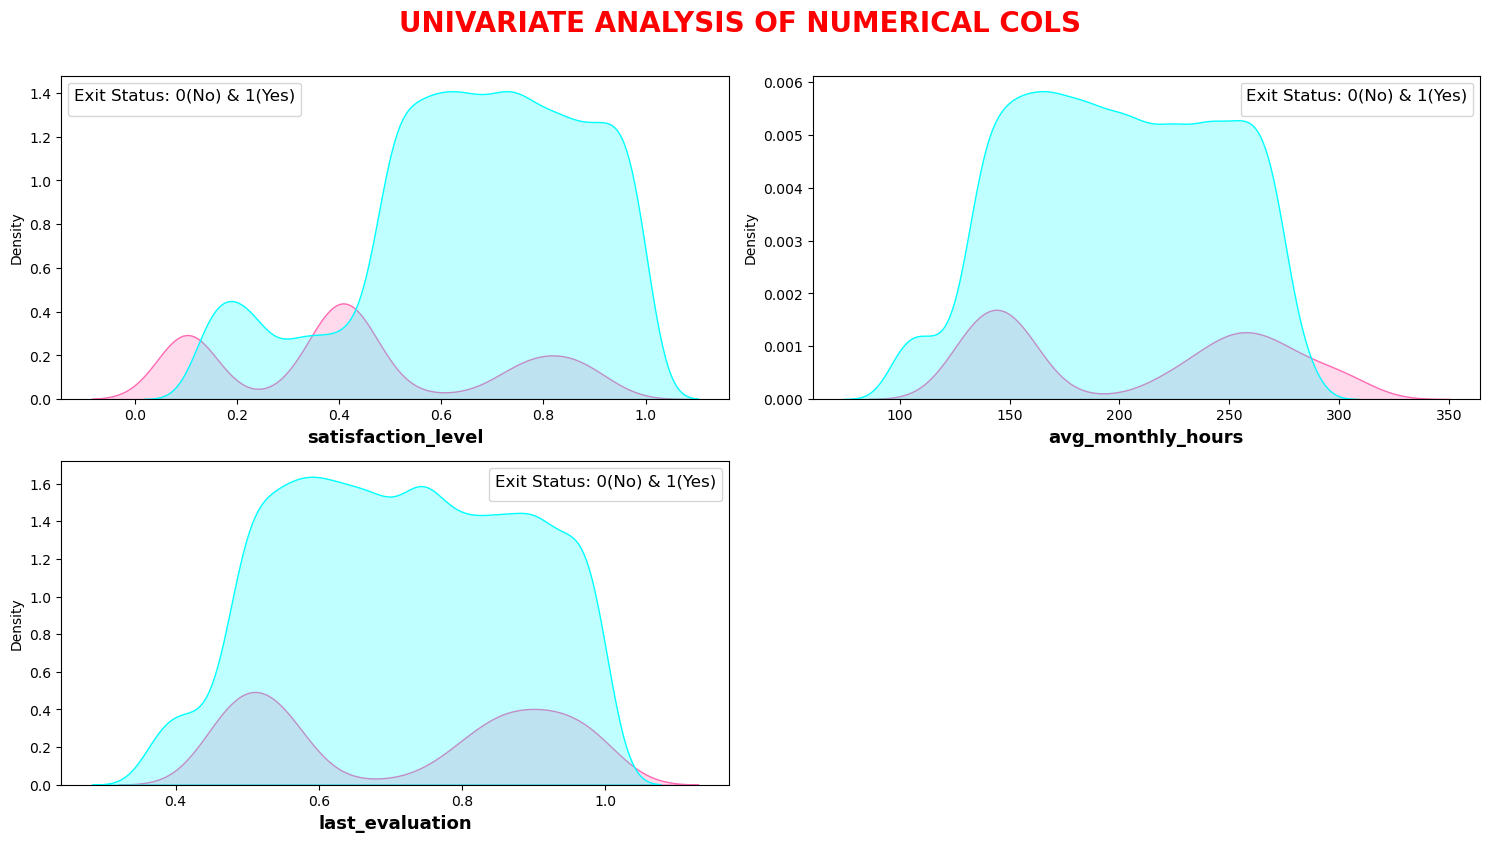

In [402]:
# Analysis of Numerical Variables in the data

col = ['satisfaction_level','avg_monthly_hours','last_evaluation']
t=1
plt.figure(figsize=[15,12])
plt.suptitle('UNIVARIATE ANALYSIS OF NUMERICAL COLS \n',fontweight='bold',color='red',size=20)
for i in col:
    plt.subplot(3,2,t)
    sns.kdeplot(data,x=i,hue='Exit_status',fill=True,palette=['aqua','hotpink'])
    t+=1
    plt.xlabel(i,fontweight='bold',size=13)
    plt.legend(title = 'Exit Status: 0(No) & 1(Yes)',title_fontsize=12)
    plt.tight_layout()
plt.show()

***Through this univariate analysis we can identify that the following inferences***:
* Most of the employees are from sales department.
* Maximum employees get low salary and very few get high salary
* Most of the employees stay in the company for 3 years and very few employees who stay for 10 years.
* Maximum employees do 4 projects in a month very few employees who do 7 projects and no employee who can complete more than 7 projects in a month
* very few employees in the organization who get promoted in last 5 years


for finding the actual reason of employee leaving the organization we need to do bivariate analysis . Before that we will do correlation analysis which will help to find which variable has the strong relation with the effect of exiting.

***

#### Heatmap

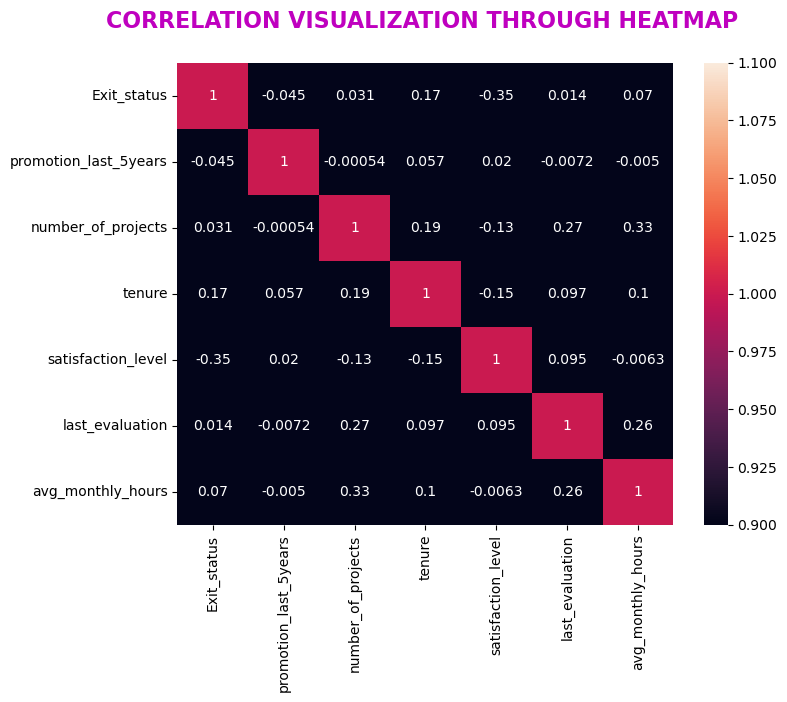

In [403]:
col = ['Exit_status','promotion_last_5years','number_of_projects','tenure','satisfaction_level','last_evaluation','avg_monthly_hours']
plt.figure(figsize=[8,6])
sns.heatmap(data[col].corr(),annot=True,vmin=1)
plt.title('CORRELATION VISUALIZATION THROUGH HEATMAP \n ',fontweight='bold',fontsize=16,color='m')
plt.show()

***

#### ***Bivariate Analysis***

for finding the actual reason of employee leaving the organization we need to do bivariate analysis . 

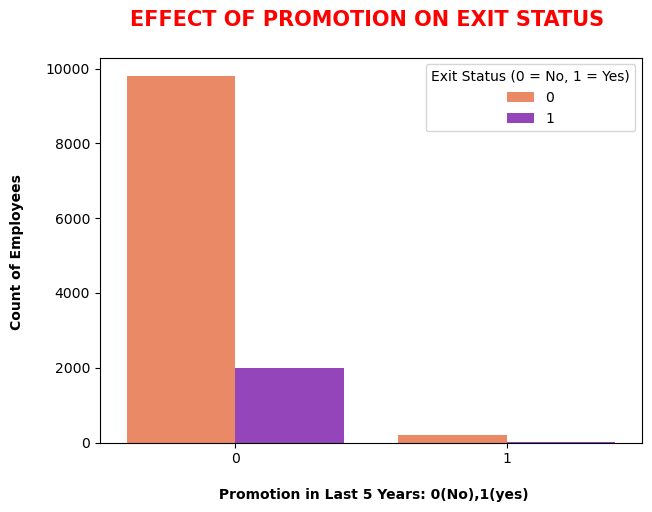

In [404]:
# Effect of promotion on exit status


plt.figure(figsize=(7,5))
sns.countplot(data=data,x='promotion_last_5years',hue='Exit_status',palette=['coral','darkorchid'])
plt.xlabel("\n Promotion in Last 5 Years: 0(No),1(yes)", fontweight="bold")
plt.ylabel("Count of Employees \n", fontweight="bold")
plt.title("EFFECT OF PROMOTION ON EXIT STATUS \n", fontweight="bold",color='Red',size=15)
plt.legend(title="Exit Status (0 = No, 1 = Yes)")
plt.show()


<Figure size 1500x2000 with 0 Axes>

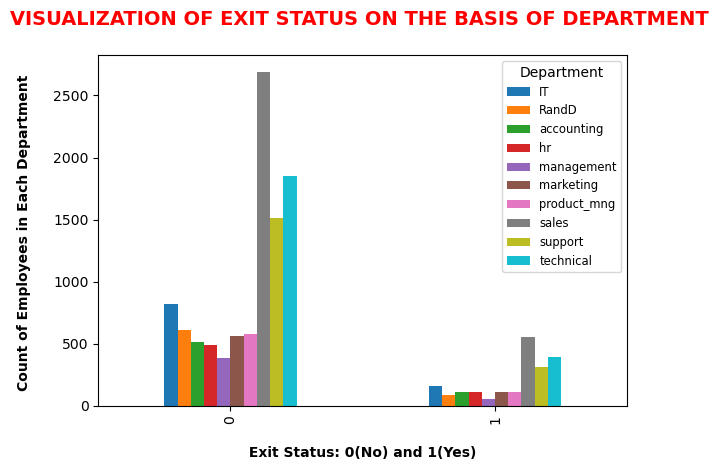

In [405]:
# Analysis of the exit status on the basis of department

plt.figure(figsize=[15,20])
pd.crosstab(data['Exit_status'],data['department']).plot(kind='bar')
plt.title('VISUALIZATION OF EXIT STATUS ON THE BASIS OF DEPARTMENT \n',fontweight='bold',color='Red',size=14)
plt.xlabel('\n Exit Status: 0(No) and 1(Yes) ',fontweight='bold')
plt.ylabel('Count of Employees in Each Department \n',fontweight = 'bold')
plt.legend(title='Department',loc='upper right',fontsize='small',title_fontsize=10)
plt.tight_layout()
plt.show()

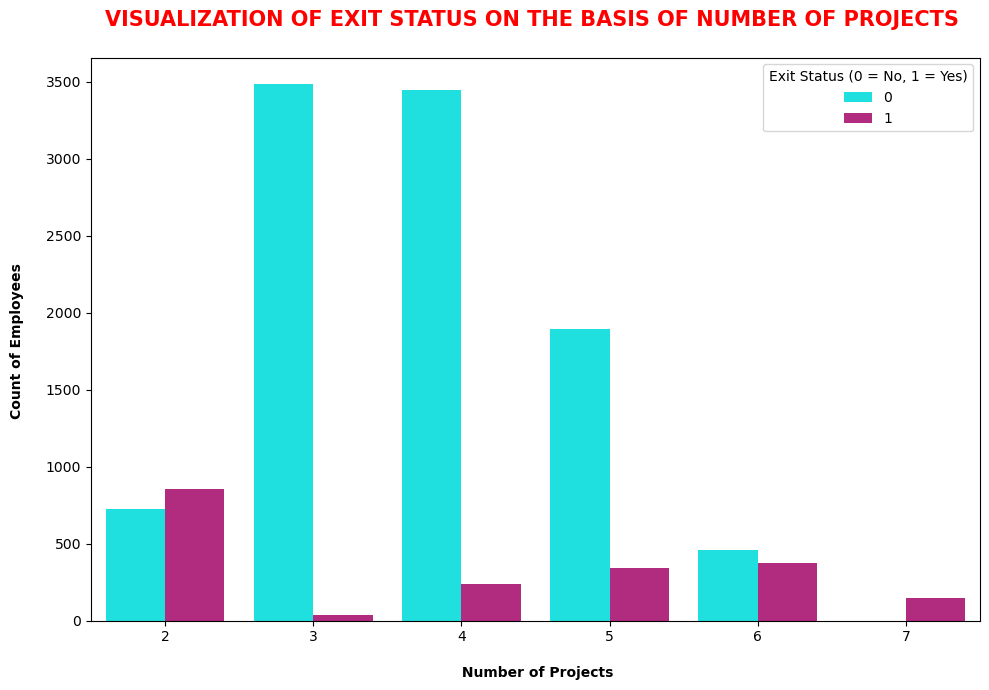

In [406]:

# Analysis of the exit status on the basis of number of projects

plt.figure(figsize=[10,7])
sns.countplot(data,x='number_of_projects', hue='Exit_status',palette=['aqua','mediumvioletred'])
plt.title('VISUALIZATION OF EXIT STATUS ON THE BASIS OF NUMBER OF PROJECTS \n',fontweight = 'bold',color='red',size=15)
plt.xlabel('\n Number of Projects',fontweight='bold')
plt.ylabel('Count of Employees \n ', fontweight='bold')
plt.legend(title="Exit Status (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

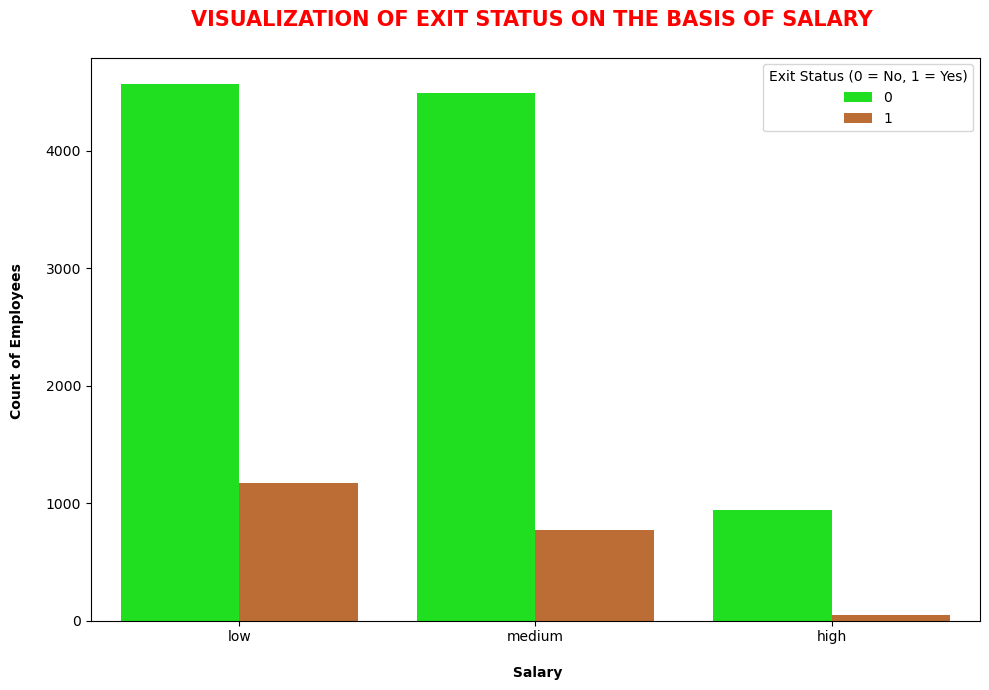

In [407]:
# Analysis of Exit status on the basis of salary

plt.figure(figsize=[10,7])
sns.countplot(data,x='salary', hue='Exit_status',palette=['lime','chocolate'])
plt.title('VISUALIZATION OF EXIT STATUS ON THE BASIS OF SALARY \n',fontweight = 'bold',color='red',size=15)
plt.xlabel('\n Salary',fontweight='bold')
plt.ylabel('Count of Employees \n ', fontweight='bold')
plt.legend(title="Exit Status (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

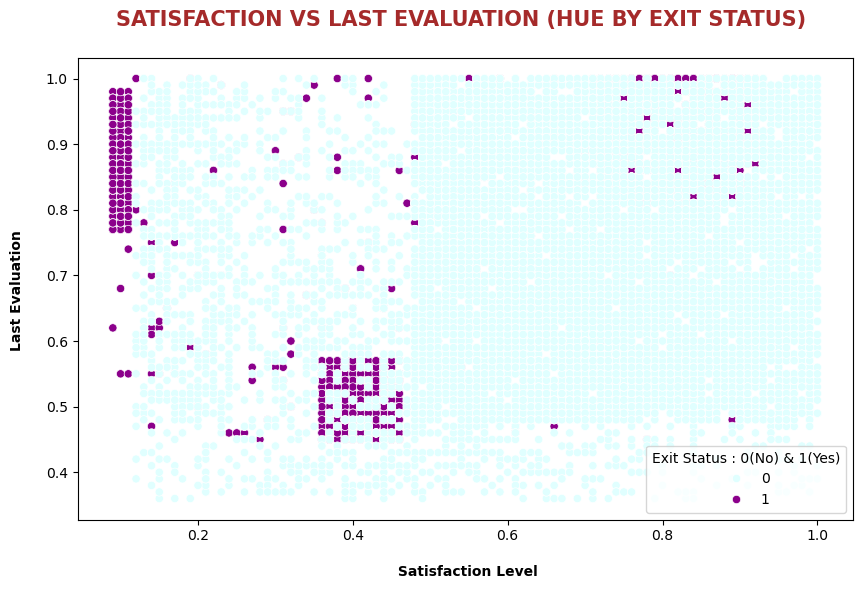

In [408]:
# Analysis of satisfaction level on the basis of Last evaluation

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='satisfaction_level', y='last_evaluation', hue='Exit_status',palette=['lightcyan','darkmagenta'])
plt.title('SATISFACTION VS LAST EVALUATION (HUE BY EXIT STATUS) \n ',fontweight = 'bold',fontsize=15,color='brown')
plt.legend(title = 'Exit Status : 0(No) & 1(Yes)')
plt.xlabel('\n Satisfaction Level',fontweight='bold')
plt.ylabel('Last Evaluation \n ',fontweight='bold')
plt.show()

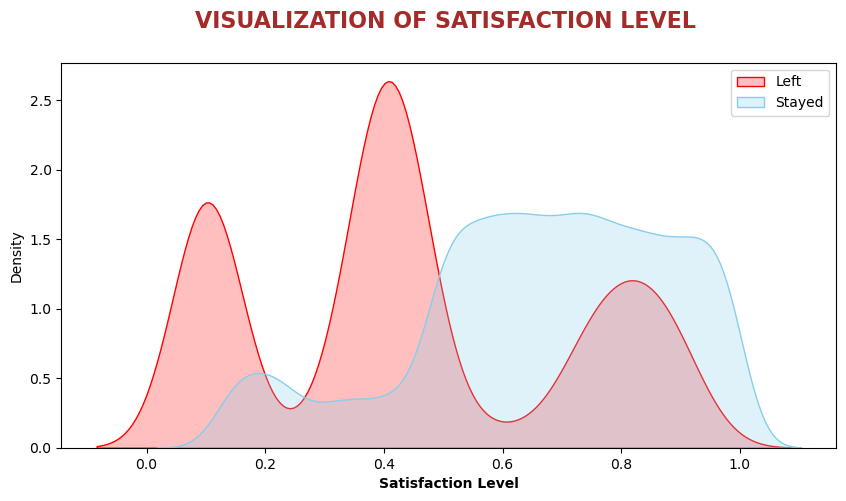

In [409]:
# Visualtion of satisfaction level for stayed and left employees in Organization

plt.figure(figsize=(10, 5))
sns.kdeplot(data=data[data['Exit_status'] == 1]['satisfaction_level'], label='Left', fill=True, color='red')
sns.kdeplot(data=data[data['Exit_status'] == 0]['satisfaction_level'], label='Stayed', fill=True, color='skyblue')
plt.title('VISUALIZATION OF SATISFACTION LEVEL \n',fontweight='bold',color='brown',size=16)
plt.xlabel('Satisfaction Level',fontweight='bold')
plt.legend()
plt.show()

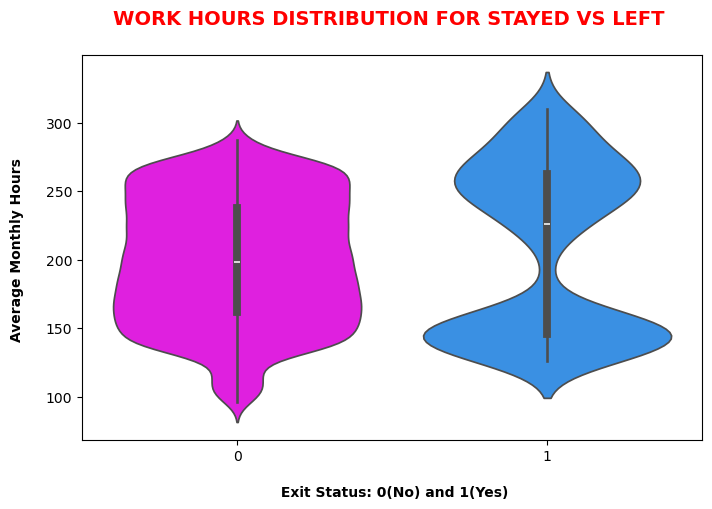

In [410]:
# Visualization of Effect of work hours on exit status

plt.figure(figsize=(8, 5))
sns.violinplot(x='Exit_status', y='avg_monthly_hours', data=data,palette=['fuchsia','dodgerblue'])
plt.title('WORK HOURS DISTRIBUTION FOR STAYED VS LEFT \n',fontweight = 'bold',size=14,color='red')
plt.xlabel(' \n Exit Status: 0(No) and 1(Yes)',fontweight='bold')
plt.ylabel('Average Monthly Hours \n' , fontweight='bold' )
plt.show()

## ***Inference on the basis of Visualization***

* By looking all the variables effect on exit status we can get some inferences which as follows:
1) Most of the employees in the organization are from sales department and the employees who exit from the organization are mostly from sales department than other departments
2) Most of the employees in the organization didn't get any promotion since last 5 years and this could be the reason of the employees to leave the organization. We find that the employees who leave the organization are mostly from the portion who didn't get promotion.
3) The employees who get low or medium salary has high chances to leave the organization than the employes who get high salary
4) Through visualization of Satisfaction level and Last evaluation we can say that : 
    * There is some employees whose last performace is good but their satisfaction level is low may be they didn't get any encouragement on their work that's why they left the organization
    * There is some employees whose last performace is low and satisfaction level is also low so i can say that they are those employees who are not interest to do their work sincerely.
    * and there is very few employees who get encouragement due to their good performance may be they got better opportunity or better salary that's why they left the organization.
5) Most of the employees who leave the organization is not much satisfied with company's encouragement criteria.
6)There are some employees who really did hard work but left the organization may be they are not satisfied with the company.

## DATA PREPROCESSING

Now I need to handle the outliers if present in the data and also need to scaling the numerical cols and encoding the categorical cols so that we can create model for this data .

#### Outlier Treatment

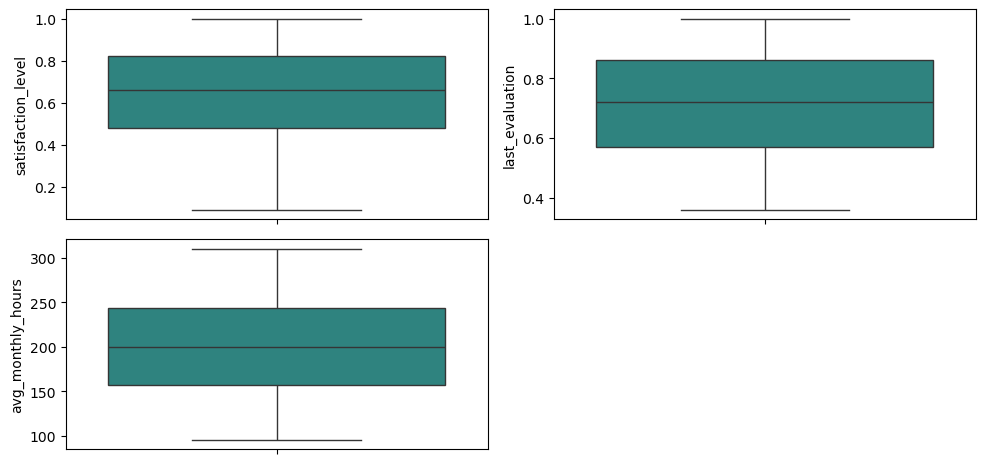

In [411]:
col = ['satisfaction_level','last_evaluation','avg_monthly_hours']
plt.figure(figsize=[10,7])
t=1
for i in col:
    plt.subplot(3,2,t)
    sns.boxplot(data[i],palette='viridis')
    t+=1
plt.tight_layout()
plt.show()

By looking this box plot visualization there is no extreme outliers present in the data which we need to treat

### Encoding Categorical Columns

In [412]:
data.nunique()

satisfaction_level        92
last_evaluation           65
number_of_projects         6
avg_monthly_hours        215
tenure                     8
work_accident              2
Exit_status                2
promotion_last_5years      2
department                10
salary                     3
dtype: int64

* For work_accident ,promotion_last_5 years,salary I am using N-1 dummy encoding because of less categories present in these variables
* for number of projects,tenure,department, exit_status I am using label encoding here and exit status is out target columns so i am using label encoding here

In [413]:
# N-1 Dummy Encoding
col = ['work_accident','promotion_last_5years','salary']
data = pd.get_dummies(data,columns=col,drop_first=True,dtype=int)

In [414]:
# Label Encoding
enc_col = ['number_of_projects','tenure','department','Exit_status']
encode = LabelEncoder()
for i in enc_col:
    data[i] = encode.fit_transform(data[i])

In [415]:
# Now I am checking all the categorical variables are encoded or not
data.head(2)

,satisfaction_level,last_evaluation,number_of_projects,avg_monthly_hours,tenure,Exit_status,department,work_accident_1,promotion_last_5years_1,salary_low,salary_medium
0,0.38,0.53,0,157,1,1,7,0,0,1,0
1,0.80,0.86,3,262,4,1,7,0,0,0,1


#### Scaling of Numerical Columns

In [416]:
# Using Power Transformer for Scaling the data

scale = PowerTransformer(method='yeo-johnson',standardize=True)
col = ['satisfaction_level','last_evaluation','avg_monthly_hours']
data[col] = scale.fit_transform(data[col])

In [417]:
data.head()

,satisfaction_level,last_evaluation,number_of_projects,avg_monthly_hours,tenure,Exit_status,department,work_accident_1,promotion_last_5years_1,salary_low,salary_medium
0,-1.078828,-1.109354,0,-0.882014,1,1,7,0,0,1,0
1,0.683566,0.851849,3,1.242418,4,1,7,0,0,0,1
2,-1.852951,0.970190,5,1.431579,2,1,7,0,0,0,1
3,0.291431,0.911026,3,0.485518,3,1,7,0,0,1,0
4,-1.112227,-1.169056,0,-0.838591,1,1,7,0,0,1,0


Now we completed all preprocessing and Transforming steps now we our data is ready for model prediction

***

### Machine Learning Model

In this data our target columns is Exit status which is in categorical form so we use Classification Models for prediction and use Logistic Regression as a baseline model for our data

#### Logistic Regression(Baseline Model)

In [418]:
x= data.drop(columns = 'Exit_status')
y= data['Exit_status']

In [421]:
# Train test split of the data
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42)

In [422]:
# Now checking the shape of the splitting data
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(8393, 10) (3598, 10) (8393,) (3598,)


In [ ]:
# Creating function for Model selection and for checking model scores

def model_selection(model_name,xtrain=x_train,ytrain=y_train,xtest=x_test):
    model_create = model_name
    model_create.fit(xtrain,ytrain)
    model_soft_pred = model_create.predict_proba(xtest)[:,1]
    model_hard_pred = model_create.predict(xtest)
    return model_soft_pred,model_hard_pred

def model_performance(preds,predh,ytest=y_test):
    print('Confusion Matrix : \n ', confusion_matrix(ytest,predh))

    print('\n Classification Report : \n ', classification_report(ytest,predh))
    print('Cohen_Kappa_Score :', cohen_kappa_score(ytest,predh))
    print('\n Accuracy Score : \n ', accuracy_score(ytest,predh))

    fpr,tpr,threshold = roc_curve(ytest,preds)
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1],ls = '--',color='red')
    plt.title(f'ROC-AUC SCORE :  {round(roc_auc_score(ytest,preds),2)}',fontweight='bold')
    plt.xlabel('FPR',fontweight='bold')
    plt.ylabel('TPR',fontweight='bold')

In [476]:
 # First Applying Logistic Regression Model

model_s,model_h = model_selection(LogisticRegression())

Confusion Matrix : 
  [[2875  120]
 [ 508   95]]

 Classification Report : 
                precision    recall  f1-score   support

           0       0.85      0.96      0.90      2995
           1       0.44      0.16      0.23       603

    accuracy                           0.83      3598
   macro avg       0.65      0.56      0.57      3598
weighted avg       0.78      0.83      0.79      3598

Cohen_Kappa_Score : 0.1581035473349346

 Accuracy Score : 
  0.8254585881045025


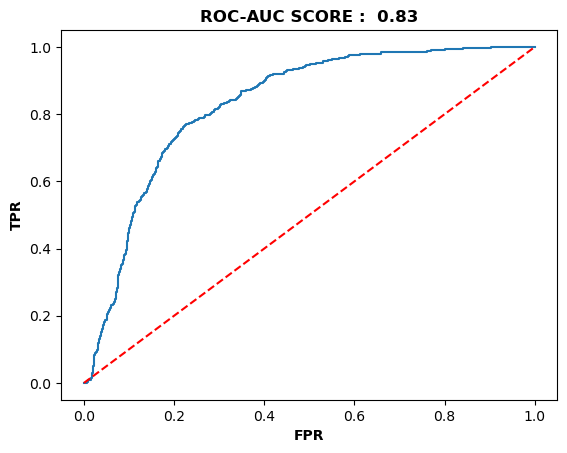

In [477]:
model_performance(model_s,model_h)

***Inference***

This model is not much good for our prediction because it is showing class imbalance in which it predicts class 0 every time which is not suitable for a good prediction and it's accuracy is 82% only and cohen kappa score is also not good for our prediction so I am choosing a some complex models so that our model can predict well .

In [ ]:
# Before moving to next model i am looking for the train score 
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [472]:
model_soft_pred = model.predict_proba(x_train)[:,1]
model_hard_pred = model.predict(x_train)
print(' Accuracy Score :  ', accuracy_score(y_train,model_hard_pred))
print('Roc-Auc Score :  ', roc_auc_score(y_train,model_soft_pred))

 Accuracy Score :   0.8312879780769689
Roc-Auc Score :   0.818638292532917


Here we can see that our train roc-auc score is high and test score is also high this shows our model is generalized but it is not suitable for our data . We need mode complex model for this data

Confusion Matrix : 
  [[2250  745]
 [  91  512]]

 Classification Report : 
                precision    recall  f1-score   support

           0       0.96      0.75      0.84      2995
           1       0.41      0.85      0.55       603

    accuracy                           0.77      3598
   macro avg       0.68      0.80      0.70      3598
weighted avg       0.87      0.77      0.79      3598

Cohen_Kappa_Score : 0.4189081161237924

 Accuracy Score : 
  0.7676486937187327


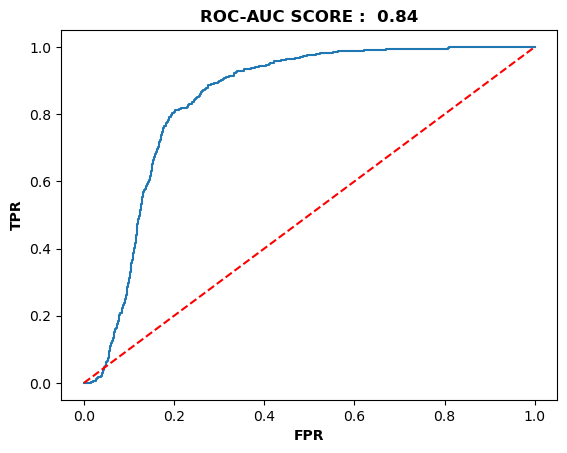

In [478]:
# The main reason for getting less recall in class 1 is because of class imbalance so if i use class = 'balanced'
model_s,model_h = model_selection(LogisticRegression(class_weight='balanced'))
model_performance(model_s,model_h)

Now we can see that our precision and accuracy is good but not much better for our model the roc-auc is less if i can't find any model whose score is much better than this model score i choose this model for my final prediction

***

### Random Forest

In [488]:
params = {'n_estimators': [100,120,130,150,190],'max_depth' :[2,4,5,6,7,8]}

gscv = GridSearchCV(estimator = RandomForestClassifier(),param_grid= params,cv=5,scoring='roc_auc',n_jobs=1)
gscv.fit(x_train,y_train)
best_params = gscv.best_params_
print(best_params)
print(gscv.best_score_)

{'max_depth': 8, 'n_estimators': 100}
0.9811304487281625


Confusion Matrix : 
  [[2981   14]
 [  60  543]]

 Classification Report : 
                precision    recall  f1-score   support

           0       0.98      1.00      0.99      2995
           1       0.97      0.90      0.94       603

    accuracy                           0.98      3598
   macro avg       0.98      0.95      0.96      3598
weighted avg       0.98      0.98      0.98      3598

Cohen_Kappa_Score : 0.9239700988424124

 Accuracy Score : 
  0.9794330183435241


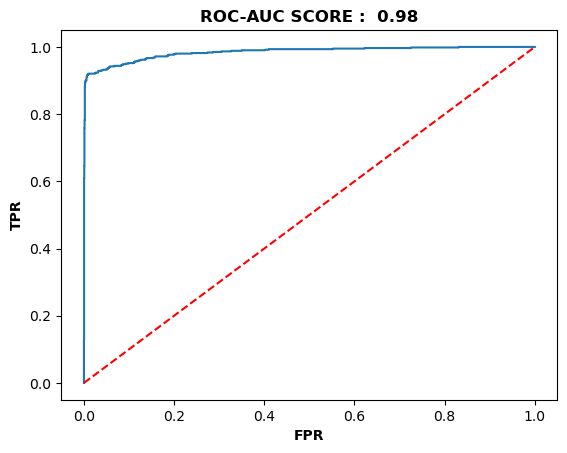

In [489]:
model_s,model_h = model_selection(RandomForestClassifier(class_weight='balanced',**best_params))
model_performance(model_s,model_h)


Random Forest seems good for our model prediction 
Accuracy score = 97%
Roc Auc score = 98%
I found this model is good for our prediction

### Gradient Boosting

In [ ]:
params = {'n_estimators': [100,120,130,150,190],'max_depth' :[2,4,5,6,7,8],'learning_rate' : [0.001,0.01,0.1,0.15,0.2]}

gscv = GridSearchCV(estimator = XGBClassifier(),param_grid= params,cv=5,scoring='roc_auc',n_jobs=1)
gscv.fit(x_train,y_train)
best_params = gscv.best_params_
print(best_params)
print(gscv.best_score_)

{'learning_rate': 0.15, 'max_depth': 4, 'n_estimators': 100}
0.9867419936297963


Confusion Matrix : 
  [[2979   16]
 [  49  554]]

 Classification Report : 
                precision    recall  f1-score   support

           0       0.98      0.99      0.99      2995
           1       0.97      0.92      0.94       603

    accuracy                           0.98      3598
   macro avg       0.98      0.96      0.97      3598
weighted avg       0.98      0.98      0.98      3598

Cohen_Kappa_Score : 0.9338047694983971

 Accuracy Score : 
  0.9819344080044469


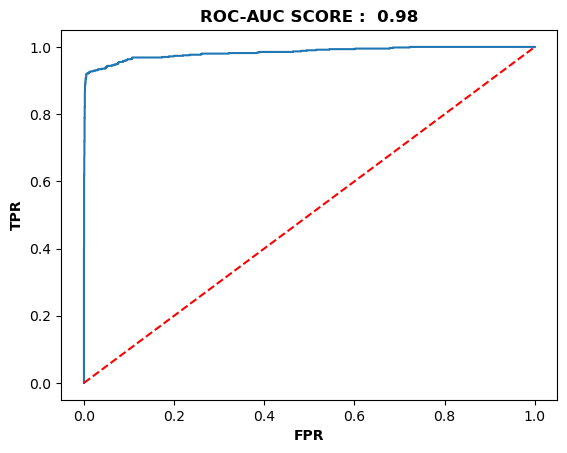

In [504]:
model_s,model_h = model_selection(XGBClassifier(class_weight='balanced',**best_params))
model_performance(model_s,model_h)


*  In XG boost model
we get accuracy of 98% 
and roc-auc score is 98% 

***

#### Final Model

#### XG Boost Classifier

As we look all the models which i created i found random forest and XG boost better model for our prediction
While comparing these two models
1) Both explained variance of around 98% of data at prediction time
2) But the accuracy score of XG boost is around 98% while Random forest score is around 97% so through this comparison I can say XG boost model is better than Random forest model . So, I am using XG boost model as a final model for our prediction

In [506]:
final_model = XGBClassifier(learning_rate=0.15, max_depth= 4, n_estimators=100,class_weight='balanced')
final_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, ...)

In [507]:
model_soft = final_model.predict_proba(x_test)[:,1]
model_hard = final_model.predict(x_test)

In [509]:
print('Classification Report : \n ', classification_report(y_test,model_hard))
print('Accuracy Score : ', accuracy_score(y_test,model_hard))
print('ROC-AUC Score ', roc_auc_score(y_test,model_soft))
      

Classification Report : 
                precision    recall  f1-score   support

           0       0.98      0.99      0.99      2995
           1       0.97      0.92      0.94       603

    accuracy                           0.98      3598
   macro avg       0.98      0.96      0.97      3598
weighted avg       0.98      0.98      0.98      3598

Accuracy Score :  0.9819344080044469
ROC-AUC Score  0.9836161429912208


#### Looking for feature Importance Through this model

In [519]:
df = pd.DataFrame({'Feature Importance' : final_model.feature_importances_},index=x_train.columns).sort_values(by='Feature Importance')

<Axes: >

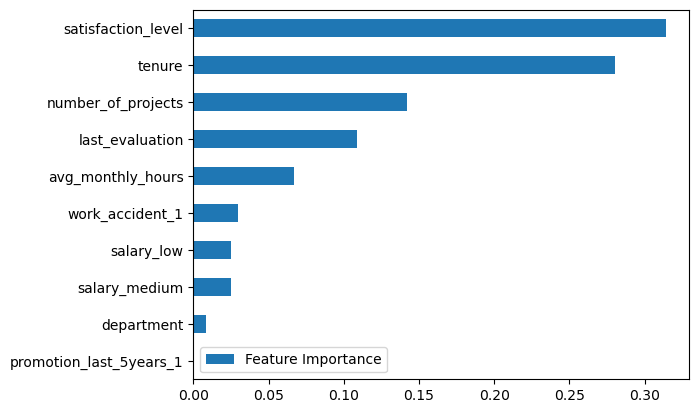

In [521]:
df.plot(kind='barh')

***
***

## ***Final Conclusion***

After Analysing the data 
* Most of the employees leave the organization because of the poor management in the coompany. Leaving the company is correlated due to long working hours,more assigned projects,not having promotion fastly,low salary and less satisfaction levels.Most of the employees who really doing very well in the company need to encourage by the company so that their satisfaction level increases.
* I also prefer to use this XG boost model for predicting the exit status of employee in advance and suggest company to improve the management of the company and take feedback time to time from the employees so that employee satisfaction got increases and the company can grow fastly in this competitive world